In [1]:
import glob
import os
from PIL import Image
import PIL.ImageStat
import shutil
import hashlib
from tqdm import tqdm
from torchvision import transforms
from helpr_fun import TransformedImageDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import sys
import matplotlib.pyplot as plt
%load_ext autoreload

%autoreload 2

c:\Users\moham\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
image_dir = os.path.abspath(r'''D:\key\2\python2\project\7\training''')

image_dir_for_search = os.path.join(image_dir, r'''**''',r'''*.jpg''')
image_list = glob.glob(image_dir_for_search , recursive=True)
images = []

im_shape = 64
resize_transforms = transforms.Compose([])


print(len(image_list))
for item in tqdm(image_list):
    with Image.open(item) as image:
        image = image.copy()
        images.append(image)

34635


100%|██████████| 34635/34635 [00:19<00:00, 1805.07it/s]


### data batching

In [3]:
from torch.utils.data import Subset
rng = np.random.default_rng(seed=0)
print(torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#split to train / validate
# train_dataset = TransformedImageDataset(images,seed = 42,augment = True)
# val_dataset = TransformedImageDataset(images,seed = 42,augment = False)
# val_dataset_augment = TransformedImageDataset(images,seed = 42,augment = True)

# if tarining on val set
train_dataset = TransformedImageDataset(images,seed = 42,augment = False)
val_dataset = TransformedImageDataset(images,seed = 42,augment = True)


# define the train and val splits
TRAIN_SPLIT = 0.80
VAL_SPLIT = 1 - TRAIN_SPLIT

n_samples = len(train_dataset)
shuffled_indices = rng.permutation(n_samples)
validation_set_indices = shuffled_indices[:int(n_samples / 5)]
training_set_indices = shuffled_indices[int(n_samples / 5):]


valData = Subset(val_dataset, indices=validation_set_indices)
trainData = Subset(train_dataset, indices=training_set_indices)
#valData_augment = Subset(val_dataset_augment, indices=validation_set_indices)

INIT_LR = 1e-3
BATCH_SIZE = 32
EPOCHS = 10



# trainDataLoader = torch.utils.data.DataLoader(trainData, shuffle=True,batch_size=BATCH_SIZE)
# valDataLoader = torch.utils.data.DataLoader(valData, batch_size=64)
# valDataLoader_augment = torch.utils.data.DataLoader(valData_augment, batch_size=BATCH_SIZE)
# if tarining on val set
valDataLoader = torch.utils.data.DataLoader(trainData, batch_size=64)
trainDataLoader = torch.utils.data.DataLoader(valData, shuffle=True,batch_size=BATCH_SIZE)

# calculate steps per epoch for training and validation set
trainSteps = len(trainDataLoader.dataset) // BATCH_SIZE
valSteps = len(valDataLoader.dataset) // BATCH_SIZE


True


In [4]:
print(torch.cuda.is_available())
device = torch.device("cuda" )

#split to train / validate
our_dataset = TransformedImageDataset(images,seed = 42,augment = True)
# define the train and val splits
TRAIN_SPLIT = 0.80
VAL_SPLIT = 1 - TRAIN_SPLIT

numTrainSamples = int(len(images) * TRAIN_SPLIT)
numValSamples = int(len(images) * VAL_SPLIT)
numValSamples += len(images)-(numTrainSamples+numValSamples)
# set the device we will be using to train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
(trainData, valData) = torch.utils.data.random_split(our_dataset,[numTrainSamples, numValSamples],generator=torch.Generator().manual_seed(42))

INIT_LR = 1e-3
BATCH_SIZE = 64
EPOCHS = 10

#trainData    = torch.utils.data.TensorDataset(torch.tensor(trainData).to(device), torch.tensor(trainData).to(device))
#valData    = torch.utils.data.TensorDataset(torch.tensor(valData).to(device), torch.tensor(valData).to(device))


trainDataLoader = torch.utils.data.DataLoader(trainData, shuffle=True,batch_size=BATCH_SIZE)
valDataLoader = torch.utils.data.DataLoader(valData, batch_size=BATCH_SIZE)
# calculate steps per epoch for training and validation set
trainSteps = len(trainDataLoader.dataset) // BATCH_SIZE
valSteps = len(valDataLoader.dataset) // BATCH_SIZE


True


In [4]:
def normalize(images_batch):
    std,mean = torch.std_mean(images_batch, dim=(2,3),keepdim=True)
    normalize_trans = transforms.Normalize(mean, std)
    norm_im = normalize_trans(images_batch)
    return norm_im,mean,std

In [5]:
def denormalize(images_batch,mean,std):
    normalize_trans = transforms.Normalize((-1 * mean / std), (1.0 / std))
    norm_im = normalize_trans(images_batch)
    return norm_im

In [79]:
class identity(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1,1,1)
        
    
    def forward( self,input_images: torch.Tensor,inputs_known_array:torch.Tensor) -> torch.Tensor:
        return input_images


i havent use this next cnn at the end

In [6]:
class SimpleCNN(nn.Module):
    def __init__(
            self,
            input_channels: int,
            hidden_channels: int,
            num_hidden_layers: int,
            use_batch_normalization: bool,
            kernel_size: int = 3,
            activation_function: nn.Module = nn.ReLU()
    ):
        super().__init__()
        self.input_channels = input_channels
        self.hidden_channels = hidden_channels
        self.num_hidden_layers = num_hidden_layers
        self.use_batch_normalization = use_batch_normalization
        self.kernel_size = kernel_size
        self.activation_function = activation_function
        
        self.conv_layers = nn.ModuleList()
        self.conv_layers.append(nn.Conv2d(
            input_channels,
            hidden_channels,
            kernel_size,
            padding="same",
            padding_mode="zeros",
            bias=not use_batch_normalization
        ))
        # We already added one conv layer, so start the range from 1 instead of 0
        for i in range(1, num_hidden_layers):
            self.conv_layers.append(nn.Conv2d(
                hidden_channels,
                hidden_channels,
                kernel_size,
                padding="same",
                padding_mode="zeros",
                bias=not use_batch_normalization
            ))
        if self.use_batch_normalization:
            self.batch_norm_layers = nn.ModuleList()
            for i in range(num_hidden_layers):
                self.batch_norm_layers.append(nn.BatchNorm2d(hidden_channels))
        self.output_layer = nn.Conv2d(
                hidden_channels+3,
                8,
                kernel_size,
                padding="same",
                padding_mode="zeros",
            )
        self.output_layer2 = nn.Conv2d(
                11,
                1,
                kernel_size,
                padding="same",
                padding_mode="zeros",
            )
        self.output_layer3 = nn.Conv2d(
                4,
                1,
                kernel_size,
                padding="same",
                padding_mode="zeros",
            )
    
    def forward(self, inputs: torch.Tensor,inputs_known_array:torch.Tensor) -> torch.Tensor:
        not_inputs_known_array = ~inputs_known_array
        not_inputs_known_array = not_inputs_known_array.to(dtype=torch.float32)
        inputs_known_array = inputs_known_array.to(dtype=torch.float32)
    
        input_images = torch.cat((inputs,inputs_known_array,not_inputs_known_array),1)
        for i in range(self.num_hidden_layers):
            input_images = self.conv_layers[i](input_images)
            if self.use_batch_normalization:
                input_images = self.batch_norm_layers[i](input_images)
            input_images = self.activation_function(input_images)
        input_images = torch.cat((input_images,inputs_known_array,not_inputs_known_array,inputs),1)
        input_images = self.output_layer(input_images)
        input_images = self.activation_function(input_images)

        input_images = torch.cat((input_images,inputs_known_array,not_inputs_known_array,inputs),1)
        input_images = self.output_layer2(input_images)
        input_images = self.activation_function(input_images)

        input_images = torch.cat((input_images,inputs_known_array,not_inputs_known_array,inputs),1)
        input_images = self.output_layer3(input_images)
        return input_images

only by adding residual connection i was able to achieve the fourth place but with good augmentation and good training procedure

In [25]:
class ResidualBlock(nn.Module):
    def __init__(self,
                 in_channels, out_channels,
                 ksize=3, stride=1, pad=1, dilation=1):
        super(ResidualBlock, self).__init__()
        self.in_eq_out = in_channels == out_channels
        self.body = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, ksize, stride, pad, dilation),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, ksize, stride, pad, dilation),
            nn.BatchNorm2d(out_channels)
        )
        if not self.in_eq_out:
            self.conv1 = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x):
        out = self.body(x)
        if not self.in_eq_out:
            x = self.conv1(x)
        return F.relu(out+x,inplace=True)
    

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.block1 = ResidualBlock(3,32)
        self.block2 = ResidualBlock(32,32)
        self.block3 = ResidualBlock(32,32)
        self.block4 = ResidualBlock(32,32)

        self.block5 = ResidualBlock(35,32)
        self.block6 = ResidualBlock(32,32)
        self.block7 = ResidualBlock(32,32)
        self.block8 = ResidualBlock(32,32)

        self.block9 = ResidualBlock(35,32)
        self.block10 = ResidualBlock(32,32)
        self.block11 = ResidualBlock(32,32)
        self.block12 = ResidualBlock(32,32)

        self.block13 = ResidualBlock(35,32)
        self.block14 = ResidualBlock(32,32)
        self.block15 = ResidualBlock(32,32)
        self.block16 = ResidualBlock(32,1)
        self.block17 = ResidualBlock(4,1)
        
        #self.outconv = nn.Conv2d(64,1,3,stride=1,padding="same")
        self.outconv2 = nn.Conv2d(4,1,3,stride=1,padding="same")

    
    def forward(self, inputs: torch.Tensor,inputs_known_array:torch.Tensor) -> torch.Tensor:
        not_inputs_known_array = ~inputs_known_array
        not_inputs_known_array = not_inputs_known_array.to(dtype=torch.float32)
        inputs_known_array = inputs_known_array.to(dtype=torch.float32)
    
        input_images = torch.cat((inputs,inputs_known_array,not_inputs_known_array),1)
        x1 = self.block1(input_images)
        x2 = self.block2(x1)
        x3 = self.block3(x2)
        x4 = self.block4(x3)

        x4 = torch.cat((x4,input_images),1)
        x5 = self.block5(x4)
        x6 = self.block6(x5)
        x7 = self.block7(x6)
        x8 = self.block8(x7)

        x8 = torch.cat((x8,input_images),1)
        x9 = self.block9(x8)
        x10 = self.block10(x9)
        x11 = self.block11(x10)
        x12 = self.block12(x11)

        x12 = torch.cat((x12,input_images),1)
        x13 = self.block13(x12)
        x14 = self.block14(x13)
        x15 = self.block15(x14)
        x16 = self.block16(x15)
        #x16 = self.outconv(x15)
        x16 = torch.cat((x16,input_images),1)
        #x17 = self.block17(x16)

        x17 = self.outconv2(x16)
        return x17

for the last exprement i thought task that are very similer to this task is super sampling so i searched for the SOTA model for super sampling and i found the best is also transformers however unlike calssification task CNNS are not far behind bcause in this kind of tasks every pixel matters which is hard for transformers that have quadratics space complicity .
so i found that the best super sampling model is calledd DRLN "https://arxiv.org/pdf/1906.12021.pdf" so i impliment it with a fewer parameter to run on my laptop .
i found it convergece very quickly at first but end up with very similr loss to the residual model at the end ,but since it was last model i tried , i end up implementing more augentation and training with validiation data at the end so it had lower loss at the end .

In [6]:
import torch
import torch.nn as nn
import ops as ops
import torch.nn.functional as F


class CALayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(CALayer, self).__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.c1 = ops.BasicBlock(channel , channel // reduction, 3, 1, 3, 3)
        self.c2 = ops.BasicBlock(channel , channel // reduction, 3, 1, 5, 5)
        self.c3 = ops.BasicBlock(channel , channel // reduction, 3, 1, 7, 7)
        self.c4 = ops.BasicBlockSig((channel // reduction)*3, channel , 3, 1, 1)

    def forward(self, x):
        y = self.avg_pool(x)
        c1 = self.c1(y)
        c2 = self.c2(y)
        c3 = self.c3(y)
        c_out = torch.cat([c1, c2, c3], dim=1)
        y = self.c4(c_out)
        return x * y

class Block(nn.Module):
    def __init__(self, in_channels, out_channels, group=1):
        super(Block, self).__init__()

        self.r1 = ops.ResidualBlock(in_channels, out_channels)
        self.r2 = ops.ResidualBlock(in_channels*2, out_channels*2)
        self.r3 = ops.ResidualBlock(in_channels*4, out_channels*4)
        self.g = ops.BasicBlock(in_channels*8, out_channels, 1, 1, 0)
        self.ca = CALayer(in_channels)

    def forward(self, x):
        c0 =  x

        r1 = self.r1(c0)
        c1 = torch.cat([c0, r1], dim=1)
                
        r2 = self.r2(c1)
        c2 = torch.cat([c1, r2], dim=1)
               
        r3 = self.r3(c2)
        c3 = torch.cat([c2, r3], dim=1)

        g = self.g(c3)
        out = self.ca(g)
        return out
        

class DRLN(nn.Module):
    def __init__(self):
        super(DRLN, self).__init__()
        

        chs=32

        
        self.head = nn.Conv2d(3, chs, 3, 1, 1)

        self.b1 = Block(chs, chs)
        self.b2 = Block(chs, chs)
        self.b3 = Block(chs, chs)
        self.b4 = Block(chs, chs)
        self.b5 = Block(chs, chs)
        self.b6 = Block(chs, chs)
        self.b7 = Block(chs, chs)
        self.b8 = Block(chs, chs)
        self.b9 = Block(chs, chs)
        self.b10 = Block(chs, chs)
        self.b11 = Block(chs, chs)
        self.b12 = Block(chs, chs)


        self.c1 = ops.BasicBlock(chs*2, chs, 3, 1, 1)
        self.c2 = ops.BasicBlock(chs*3, chs, 3, 1, 1)
        self.c3 = ops.BasicBlock(chs*4, chs, 3, 1, 1)
        self.c4 = ops.BasicBlock(chs*2, chs, 3, 1, 1)
        self.c5 = ops.BasicBlock(chs*3, chs, 3, 1, 1)
        self.c6 = ops.BasicBlock(chs*4, chs, 3, 1, 1)
        self.c7 = ops.BasicBlock(chs*2, chs, 3, 1, 1)
        self.c8 = ops.BasicBlock(chs*3, chs, 3, 1, 1)
        self.c9 = ops.BasicBlock(chs*4, chs, 3, 1, 1)
        self.c10 = ops.BasicBlock(chs*2, chs, 3, 1, 1)
        self.c11 = ops.BasicBlock(chs*3, chs, 3, 1, 1)
        self.c12 = ops.BasicBlock(chs*4, chs, 3, 1, 1)

        self.tail = nn.Conv2d(chs, 1, 3, 1, 1)
                
    def forward(self, x,inputs_known_array):
        not_inputs_known_array = ~inputs_known_array
        not_inputs_known_array = not_inputs_known_array.to(dtype=torch.float32)
        inputs_known_array = inputs_known_array.to(dtype=torch.float32)
        x = torch.cat((x,inputs_known_array,not_inputs_known_array),1)

        x = self.head(x)
        c0 = o0 = x

        b1 = self.b1(o0)
        c1 = torch.cat([c0, b1], dim=1)
        o1 = self.c1(c1)
        
        b2 = self.b2(o1)
        c2 = torch.cat([c1, b2], dim=1)
        o2 = self.c2(c2)
        
        b3 = self.b3(o2)
        c3 = torch.cat([c2, b3], dim=1)
        o3 = self.c3(c3)
        a1 = o3 + c0

        b4 = self.b4(a1)
        c4 = torch.cat([o3, b4], dim=1)
        o4 = self.c4(c4)
 
        b5 = self.b5(a1)
        c5 = torch.cat([c4, b5], dim=1)
        o5 = self.c5(c5)

        b6 = self.b6(o5)
        c6 = torch.cat([c5, b6], dim=1)
        o6 = self.c6(c6)
        a2 = o6 + a1

        b7 = self.b7(a2)
        c7 = torch.cat([o6, b7], dim=1)
        o7 = self.c7(c7)

        b8 = self.b8(o7)
        c8 = torch.cat([c7, b8], dim=1)
        o8 = self.c8(c8)

        b9 = self.b9(o8)
        c9 = torch.cat([c8, b9], dim=1)
        o9 = self.c9(c9)
        a3 = o9 + a2

        b10 = self.b10(a3)
        c10 = torch.cat([o9, b10], dim=1)
        o10 = self.c10(c10)


        b11 = self.b11(o10)
        c11 = torch.cat([c10, b11], dim=1)
        o11 = self.c11(c11)

        b12 = self.b12(o11)
        c12 = torch.cat([c11, b12], dim=1)
        o12 = self.c12(c12)
        a4 = o12 + a3

    
        b_out = a4 + x

        out = self.tail(b_out)

        return out





In [7]:
def eval_fun():
    i = 0
    net.eval().cpu()
    criterion = nn.MSELoss()
    loss_list = []
    for pixelated_image, known_array, original_im in tqdm(valDataLoader):
        if i == 109 :
            break
        i += 1
        inputs_known_array = known_array
        inputs = pixelated_image.to(dtype=torch.float32)

        
        inputs,mean,std = normalize(inputs)
        outputs = net(inputs,inputs_known_array)
        outputs = denormalize(outputs,mean,std)

        target = original_im[~known_array].to(dtype=torch.float32)
        preds = outputs[~known_array].to(dtype=torch.float32) 
        loss = criterion(target, preds)
        loss_list.append(loss.item())


        # print statistics
    return np.array(loss_list).mean()

In [10]:

eval_loss = eval_fun()
print(f'eval loss {eval_loss:.3f} eval RMSE {eval_loss**.5:.3f}')

 25%|██▌       | 109/433 [17:22<51:38,  9.56s/it] 


eval loss 320.783 eval RMSE 17.910


In [17]:
def eval_fun_augment():
    net.eval()
    criterion = nn.MSELoss()
    loss_list = []
    for pixelated_image, known_array, original_im in valDataLoader_augment:
        
        inputs_known_array = known_array.to(device)
        inputs = pixelated_image.to(device).to(dtype=torch.float32)

        
        inputs,mean,std = normalize(inputs)
        outputs = net(inputs,inputs_known_array)
        outputs = denormalize(outputs,mean,std)

        target = original_im[~known_array].to(device).to(dtype=torch.float32)
        preds = outputs[~known_array].to(device).to(dtype=torch.float32) 

        loss = criterion(target, preds)
        loss_list.append(loss.item())


        # print statistics
    return np.array(loss_list).mean()

 receptive field calculation $r_0 = \sum_{l=1}^{L}((k_l-1)\prod_{i_1}^{l-1}s_i)+1$

### trainig procedure 
- train until model strats to overfit then add more augemtation 
- add augmentation that are more suitable and safe first then add the more modifying augmentation later
- when the model stops improving divid the lr by 10
- in the end train on the validation set for a couple of epochs
- "note i have only implemented the last procedure on DRLN result and not on the residual cnn "

In [12]:
import torch.optim as optim


#net = SimpleCNN(3,32,32,use_batch_normalization = True  )

# net = DRLN()
net.cuda()
criterion = nn.MSELoss()

loss_list = []
eaval_loss_list = []
train_loss_list = []

optimizer = optim.Adam(net.parameters(),.00001,weight_decay=1e-4)
for epoch in range(1):  # loop over the dataset multiple times
    loss_list = []
    net.train()
    net.cuda()
    running_loss = 0.0
    for pixelated_image, known_array, original_im in tqdm(trainDataLoader, file=sys.stdout):
        
        inputs_known_array = known_array.to(device)
        inputs = pixelated_image.to(device).to(dtype=torch.float32)

        inputs,mean,std = normalize(inputs)
        outputs = net(inputs,inputs_known_array)
        outputs = denormalize(outputs,mean,std)

        # target = original_im.to(device).to(dtype=torch.float32)
        # preds = outputs.to(device).to(dtype=torch.float32) 
        
        target = original_im[~known_array].to(device).to(dtype=torch.float32)
        preds = outputs[~known_array].to(device).to(dtype=torch.float32) 
        #print(preds)
        optimizer.zero_grad()
        loss = criterion(target, preds)
        loss.backward()    
        optimizer.step()
        
        


        # print statistics
        loss_list.append(loss.item())

    curr_loss = np.array(loss_list).mean()


    eval_loss = eval_fun()

    train_loss_list.append(curr_loss)
    eaval_loss_list.append(eval_loss)
    print(f'[{epoch + 1}] train loss: {curr_loss :.3f} train RMSE : {curr_loss**.5 :.5f} eval loss {eval_loss:.3f} eval RMSE {eval_loss**.5:.3f} ')
 


print('Finished Training')


100%|██████████| 217/217 [04:06<00:00,  1.14s/it]


 25%|██▌       | 109/433 [17:35<52:18,  9.69s/it] 


[1] train loss: 844.410 train RMSE : 29.05873 eval loss 320.999 eval RMSE 17.916 
Finished Training


In [11]:
torch.save(net, r'''D:\key\2\python2\project\7\DRLN_with_eval.pt''')

In [8]:
net = DRLN()
net = torch.load(r'''D:\key\2\python2\project\7\DRLN_with_eval.pt''')
net.eval()

DRLN(
  (head): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (b1): Block(
    (r1): ResidualBlock(
      (body): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (r2): ResidualBlock(
      (body): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (r3): ResidualBlock(
      (body): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (g): BasicBlock(
      (body): Sequential(
        (0): Conv2d(256, 32, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplac

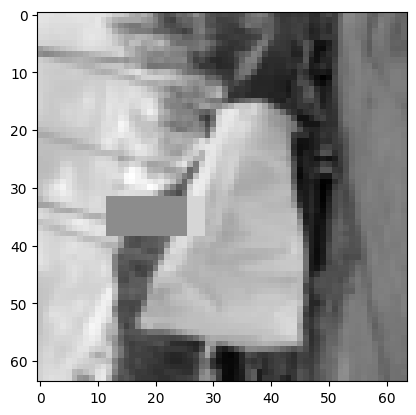

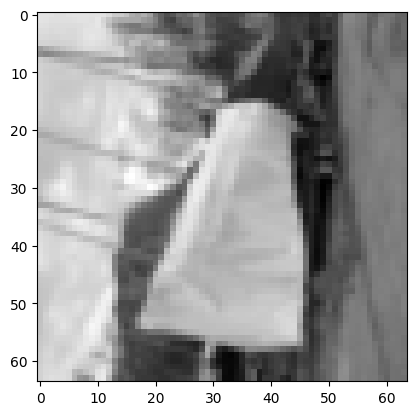

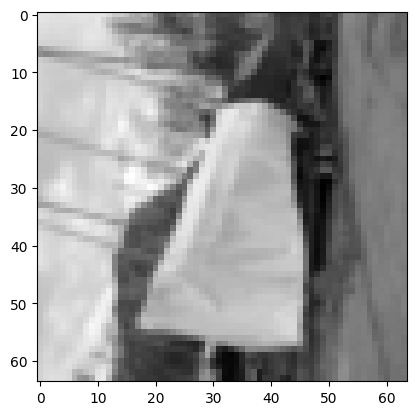

In [68]:

for epoch in range(128):  # loop over the dataset multiple times
    net.eval()
    for pixelated_image, known_array, original_im in valDataLoader:
        known_array = known_array.to(device)
        inputs_known_array = known_array.to(device)
        #inputs_known_array = known_array.to(dtype=torch.float32)
        inputs = pixelated_image.to(device).to(dtype=torch.float32)
        
        inputs,mean,std = normalize(inputs)
        outputs = net(inputs,inputs_known_array)
        outputs = denormalize(outputs,mean,std)

        
        preds = outputs.detach()*~known_array+(original_im.to(device).to(dtype=torch.float32))*known_array
        #print(pixelated_image[0,:,20:40,20:40].squeeze().cpu().numpy().round().astype('uint8'))
        plt.imshow(pixelated_image[0].squeeze().cpu().numpy().round().astype('uint8'),cmap='gray')
        plt.show()
        plt.imshow(preds[0].squeeze().cpu().numpy().round().astype('uint8'),cmap='gray')
        plt.show()
        plt.imshow(original_im[0].squeeze().cpu().numpy().round().astype('uint8'),cmap='gray')
        break
        
    break





[507.25063778938505, 426.8842385668273, 405.8098218725362, 390.61409850514264, 380.09494760495807, 374.8495386806103, 373.24948008126074, 370.0114811888528, 369.65078371380446, 364.5224048019549, 367.7394570166912, 369.7160424748692, 368.990105305243, 370.29633002324937, 376.681016834504, 376.55833771031934, 377.35575432733657, 368.8540323239948, 366.75827936294974, 360.0356369718499, 360.9314138429974, 352.3310205302107, 354.12703907817877, 353.3177045069703, 350.5437557675423, 351.4650552732135, 350.8961992176301, 349.959347366193, 350.0224388192553, 349.878940827256, 349.5261804423201, 348.6892886380537, 350.1015924576226, 351.28573412413994, 350.2796468472262, 349.7714525975219, 354.40745068471364, 354.0217196963249, 349.3574073161554, 347.4066657670047, 346.5779455342424, 349.44664435430406, 336.28599548339844, 334.9751302736615, 335.4008640674276, 335.99257232945996, 336.7657802476796, 341.85841733600023, 345.11304858846404, 341.28468658727246, 342.3937635509246, 341.757093517058

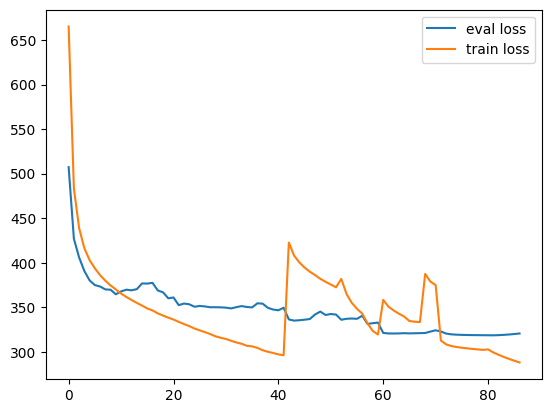

In [32]:
print(eaval_loss_list)
plt.plot(eaval_loss_list,label='eval loss')
plt.plot(train_loss_list,label = 'train loss')
plt.legend()


In [15]:
torch.cuda.empty_cache()

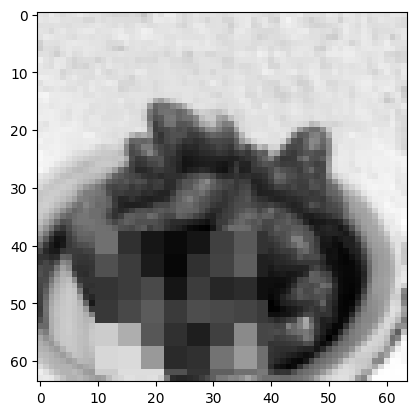

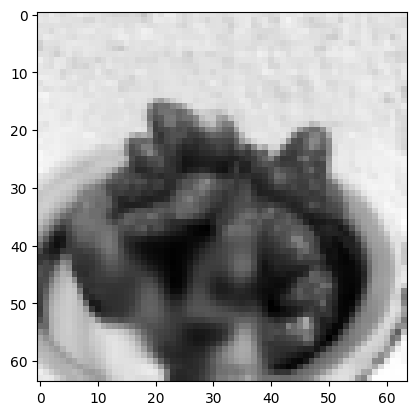

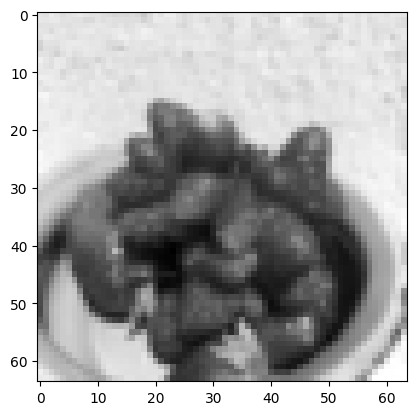

In [9]:

for epoch in range(128):  # loop over the dataset multiple times
    net.eval()
    for pixelated_image, known_array, original_im in valDataLoader:
        known_array = known_array
        inputs_known_array = known_array
        #inputs_known_array = known_array.to(dtype=torch.float32)
        inputs = pixelated_image.to(dtype=torch.float32)
        
        inputs,mean,std = normalize(inputs)
        outputs = net(inputs,inputs_known_array)
        outputs = denormalize(outputs,mean,std)

        
        preds = outputs.detach()*~known_array+(original_im.to(dtype=torch.float32))*known_array
        #print(pixelated_image[0,:,20:40,20:40].squeeze().cpu().numpy().round().astype('uint8'))
        plt.imshow(pixelated_image[0].squeeze().cpu().numpy().round().astype('uint8'),cmap='gray')
        plt.show()
        plt.imshow(preds[0].squeeze().cpu().numpy().round().astype('uint8'),cmap='gray')
        plt.show()
        plt.imshow(original_im[0].squeeze().cpu().numpy().round().astype('uint8'),cmap='gray')
        break
        
    break





In [11]:

import pickle
from torch.utils.data import Dataset
data = None
with open(r'D:\key\2\python2\project\7\sub\test_set.pkl', 'rb') as f:
    data = pickle.load(f)


class test_set(Dataset):
    
    def __init__(self, dataset):
        self.dataset = dataset
    
    def __getitem__(self, index: int):
        
        pixelated_image = self.dataset['pixelated_images'][index]
        known_array = self.dataset['known_arrays'][index]
        return pixelated_image, known_array

    def __len__(self):
        return len(self.dataset['pixelated_images'])

#print(pixelated_images)
BATCH_SIZE = 1
test_data = test_set(data)
testDataLoader = torch.utils.data.DataLoader(test_data, batch_size=BATCH_SIZE)

pred_list = []
for pixelated_image,known_array in testDataLoader:
    inputs_known_array = known_array.to(device)
    inputs = pixelated_image.to(device).to(dtype=torch.float32)
    net.cuda()

    
    inputs,mean,std = normalize(inputs)
    outputs = net(inputs,inputs_known_array)
    outputs = denormalize(outputs,mean,std)

    preds = outputs[~known_array].to(device).cpu().detach().numpy().round().astype('uint8')
    pred_list.append(preds)
    # preds = outputs.detach()*~inputs_known_array+(pixelated_image.to(device).to(dtype=torch.float32))*inputs_known_array
    # plt.imshow(pixelated_image[0].squeeze().cpu().numpy().round().astype('uint8'),cmap='gray')
    # plt.show()
    # plt.imshow(preds[0].squeeze().cpu().numpy().round().astype('uint8'),cmap='gray')
    # plt.show()
print(len(pred_list))

6635


In [54]:
from submission_serialization import serialize,deserialize
serialize(submission=pred_list, path_or_filehandle = r'D:\key\2\python2\project\7\DRLN_pred_with_val.pkl')